In [19]:
import os
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wav


### 1. Tiền xử lý tín hiệu & Nạp dữ liệu


In [20]:
@dataclass
class AudioSignal:
    name: str
    wav_path: Path
    fs: int
    signal: np.ndarray
    duration_sec: float
    is_phone: bool
    gt_segments: list[tuple[float, float]]
    gt_boundaries: list[float]


def preprocessing(wav_path: Path | str) -> tuple[int, np.ndarray]:
    """Đọc file WAV và chuẩn hoá biên độ về float32 [-1.0, 1.0]."""
    fs, x = wav.read(wav_path)

    if np.issubdtype(x.dtype, np.floating):
        preprocessed = x.astype(np.float32)
    elif np.issubdtype(x.dtype, np.signedinteger):
        max_limit = np.iinfo(x.dtype).max + 1
        preprocessed = x.astype(np.float32) / max_limit
    elif x.dtype == np.uint8:
        preprocessed = (x.astype(np.float32) - 128) / 128.0
    else:
        raise ValueError(f"Không hỗ trợ định dạng dữ liệu WAV: {x.dtype}")

    return int(fs), preprocessed


def parse_lab(lab_path: Path | str) -> dict:
    """Đọc file nhãn .lab trích xuất các mốc biên chuẩn và đoạn speech/silence."""
    path = Path(lab_path)
    if not path.is_file():
        return {"speech_segments": [], "boundaries": [], "f0_mean": None, "f0_std": None}

    merged_segments = []
    f0_mean = None
    f0_std = None

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            first_word = parts[0].lower()
            if first_word == "f0mean" and len(parts) >= 2:
                f0_mean = float(parts[1])
            elif first_word == "f0std" and len(parts) >= 2:
                f0_std = float(parts[1])
            elif len(parts) >= 3:
                start = float(parts[0])
                end = float(parts[1])
                tag = parts[2].lower()
                current_label = "silence" if tag == "sil" else "speech"

                if merged_segments and merged_segments[-1]["label"] == current_label:
                    merged_segments[-1]["end"] = end
                else:
                    merged_segments.append({"start": start, "end": end, "label": current_label})

    boundaries = []
    for i in range(1, len(merged_segments)):
        boundaries.append(round(merged_segments[i]["start"], 2))

    speech_segments = [(seg["start"], seg["end"]) for seg in merged_segments if seg["label"] == "speech"]

    return {
        "speech_segments": speech_segments,
        "boundaries": boundaries,
        "f0_mean": f0_mean,
        "f0_std": f0_std,
    }


def load_dataset(folder_name: str) -> list[AudioSignal]:
    """Nạp danh sách AudioSignal từ thư mục dữ liệu."""
    search_dirs = [Path(folder_name), Path("data") / folder_name, Path.cwd() / folder_name, Path.cwd() / "data" / folder_name]
    dataset_dir = next((d for d in search_dirs if d.is_dir()), None)
    if dataset_dir is None:
        raise FileNotFoundError(f"Không tìm thấy thư mục dữ liệu: {folder_name}")

    signals = []
    for wav_file in sorted(dataset_dir.glob("*.wav")):
        fs, signal = preprocessing(wav_file)
        duration = float(len(signal) / fs)
        lab_data = parse_lab(wav_file.with_suffix(".lab"))
        is_phone = "phone" in wav_file.stem.lower()

        signals.append(
            AudioSignal(
                name=wav_file.stem,
                wav_path=wav_file,
                fs=fs,
                signal=signal,
                duration_sec=duration,
                is_phone=is_phone,
                gt_segments=lab_data["speech_segments"],
                gt_boundaries=lab_data["boundaries"],
            )
        )
    return signals

train_signals = load_dataset("TinHieuHuanLuyen")
print(f"Đã nạp {len(train_signals)} file huấn luyện: {[s.name for s in train_signals]}")


Đã nạp 4 file huấn luyện: ['phone_F1', 'phone_M1', 'studio_F1', 'studio_M1']


/tmp/ipykernel_50847/3172535124.py:15: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wav.read(wav_path)


### 2. Trích xuất đặc trưng Năng lượng ngắn hạn (STE) & Tần số F0


In [21]:
def apply_framing(
    signal: np.ndarray,
    fs: int,
    frame_size_ms: float = 25.0,
    frame_shift_ms: float = 10.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Chia tín hiệu thành các khung có độ chồng chập (frames, timestamps)."""
    frame_len = int(round(frame_size_ms * 1e-3 * fs))
    frame_shift = int(round(frame_shift_ms * 1e-3 * fs))

    num_frames = int(np.floor((len(signal) - frame_len) / frame_shift)) + 1
    frames = np.zeros((num_frames, frame_len), dtype=np.float32)
    timestamps = np.zeros(num_frames, dtype=np.float64)

    for i in range(num_frames):
        start = i * frame_shift
        end = start + frame_len
        frames[i] = signal[start:end]
        timestamps[i] = (start + frame_len / 2.0) / fs

    return frames, timestamps


def compute_ste(frames: np.ndarray) -> np.ndarray:
    """Tính năng lượng ngắn hạn (Short-Time Energy) trên từng khung."""
    return np.sum(frames**2, axis=1)


def normalize_minmax(feature: np.ndarray) -> np.ndarray:
    """Chuẩn hóa giá trị đặc trưng về đoạn [0, 1]."""
    f_min = np.min(feature)
    f_max = np.max(feature)
    denom = f_max - f_min
    if denom > 0:
        return (feature - f_min) / denom
    return np.zeros_like(feature)


def estimate_f0_track(
    signal: np.ndarray,
    fs: int,
    timestamps: np.ndarray,
    frame_len_ms: float = 25.0,
    f0_min: float = 60.0,
    f0_max: float = 400.0,
    voicing_thresh: float = 0.35,
) -> np.ndarray:
    """Ước lượng đường tần số cơ bản F0 theo chuỗi khung bằng hàm tự tương quan."""
    frame_len = int(round(frame_len_ms * 1e-3 * fs))
    f0_hz = np.full(len(timestamps), np.nan)
    x = signal.astype(np.float64)
    total_samples = len(x)

    min_lag = int(round(fs / f0_max))
    max_lag = int(round(fs / f0_min))

    for i, t in enumerate(timestamps):
        start = int(round(t * fs - frame_len / 2.0))
        end = start + frame_len
        if start >= 0 and end <= total_samples:
            frame = x[start:end] - np.mean(x[start:end])
            if np.max(np.abs(frame)) > 1e-6:
                corr = np.correlate(frame, frame, mode="full")
                corr = corr[len(corr) // 2:]
                max_lag_local = min(max_lag, len(corr) - 1)
                if max_lag_local > min_lag:
                    search_zone = corr[min_lag:max_lag_local]
                    peak_idx = int(np.argmax(search_zone)) + min_lag
                    confidence = corr[peak_idx] / (corr[0] + 1e-10)
                    if confidence >= voicing_thresh and peak_idx > 0:
                        f0_hz[i] = float(fs / peak_idx)

    return f0_hz


### 3. Huấn luyện tìm ngưỡng tối ưu bằng Phân phối chuẩn Gaussian (Bayes Quadratic)

Giải phương trình đẳng mật độ xác suất giữa 2 phân phối chuẩn Gauss (Bayes Decision Boundary):
$$p(x \mid \text{silence}) = p(x \mid \text{speech})$$

Phương trình phân định bậc hai (Bayes Quadratic):
$$A \cdot x^2 + B \cdot x + C = 0$$

Trong đó:
$$A = \frac{1}{2\sigma_{\text{sil}}^2} - \frac{1}{2\sigma_{\text{sp}}^2}, \quad B = -\left(\frac{\mu_{\text{sil}}}{\sigma_{\text{sil}}^2} - \frac{\mu_{\text{sp}}}{\sigma_{\text{sp}}^2}\right), \quad C = \frac{\mu_{\text{sil}}^2}{2\sigma_{\text{sil}}^2} - \frac{\mu_{\text{sp}}^2}{2\sigma_{\text{sp}}^2} + \ln\left(\frac{\sigma_{\text{sil}}}{\sigma_{\text{sp}}}\right)$$

Ngưỡng tối ưu $T^*$ là nghiệm thực nằm trong khoảng kỳ vọng $[\mu_{\text{sil}}, \mu_{\text{sp}}]$.

In [22]:
def solve_threshold(mu_sil: float, std_sil: float, mu_sp: float, std_sp: float) -> float:
    """
    Tìm nghiệm phương trình phân định Bayes bậc hai (Bayes Quadratic) phân tách 2 phân phối Gaussian:
    """
    var_sil = max(std_sil ** 2, 1e-12)
    var_sp = max(std_sp ** 2, 1e-12)

    A = 1.0 / (2.0 * var_sil) - 1.0 / (2.0 * var_sp)
    B = - (mu_sil / var_sil - mu_sp / var_sp)
    C = (mu_sil ** 2 / (2.0 * var_sil) - mu_sp ** 2 / (2.0 * var_sp) + np.log(std_sil / std_sp))

    roots = np.roots([A, B, C])
    low = min(mu_sil, mu_sp)
    high = max(mu_sp, mu_sil)
    valid_roots = [float(np.real(r)) for r in roots if np.isreal(r) and low <= r <= high]

    if valid_roots:
        return valid_roots[0]

    # Fallback về công thức trọng số nếu cả hai nghiệm đều ngoài biên [mu_sil, mu_sp]
    denom = std_sp + std_sil
    return float((mu_sil * std_sp + mu_sp * std_sil) / denom if denom > 0 else (mu_sil + mu_sp) / 2.0)


def find_threshold_gaussian(
    ste_list: np.ndarray,
    labels_list: np.ndarray,
) -> tuple[float, float, float, float, float]:
    """Tính tham số phân phối Gauss và ngưỡng phân cách"""
    silence_values = ste_list[labels_list == 0]
    speech_values = ste_list[labels_list == 1]

    mean_sil = float(np.mean(silence_values)) if len(silence_values) > 0 else 0.001
    std_sil = float(np.std(silence_values)) if len(silence_values) > 0 else 0.001
    mean_sp = float(np.mean(speech_values)) if len(speech_values) > 0 else 0.1
    std_sp = float(np.std(speech_values)) if len(speech_values) > 0 else 0.05

    threshold = solve_threshold(mean_sil, std_sil, mean_sp, std_sp)
    return float(threshold), mean_sp, std_sp, mean_sil, std_sil


# Huấn luyện trên toàn bộ tập train
all_ste = []
all_labels = []

for sig in train_signals:
    frames, timestamps = apply_framing(sig.signal, sig.fs)
    ste_raw = compute_ste(frames)
    ste_norm = normalize_minmax(ste_raw)

    frame_lbls = np.zeros(len(timestamps), dtype=int)
    for start_t, end_t in sig.gt_segments:
        frame_lbls[(timestamps >= start_t) & (timestamps <= end_t)] = 1

    all_ste.append(ste_norm)
    all_labels.append(frame_lbls)

all_ste = np.concatenate(all_ste)
all_labels = np.concatenate(all_labels)

T_gaussian, mean_sp, std_sp, mean_sil, std_sil = find_threshold_gaussian(all_ste, all_labels)

print("=== HUẤN LUYỆN TOÀN CỤC BẰNG MÔ HÌNH BAYES QUADRATIC ===")
print(f"Phân phối Silence: Mean = {mean_sil:.6f}, Std = {std_sil:.6f}")
print(f"Phân phối Speech : Mean = {mean_sp:.6f}, Std = {std_sp:.6f}")
print(f"Ngưỡng tối ưu Bayes Quadratic T_gaussian = {T_gaussian:.6f}")

=== HUẤN LUYỆN TOÀN CỤC BẰNG MÔ HÌNH BAYES QUADRATIC ===
Phân phối Silence: Mean = 0.000249, Std = 0.000634
Phân phối Speech : Mean = 0.202467, Std = 0.235694
Ngưỡng tối ưu Bayes Quadratic T_gaussian = 0.002495


       BẢNG KẾT QUẢ ĐỊNH LƯỢNG THAM SỐ PHÂN PHỐI GAUSS TRÊN TẬP HUẤN LUYỆN
Tên File     N_sil    N_sp     mean_sil      std_sil       mean_sp       std_sp        Ngưỡng T  
----------------------------------------------------------------------------------------
phone_F1     100      222      0.000417      0.000389      0.168738      0.227280      0.001835  
phone_M1     108      306      0.000598      0.001076      0.184925      0.231175      0.004224  
studio_F1    137      147      0.000096      0.000484      0.325464      0.247925      0.001918  
studio_M1    152      119      0.000029      0.000072      0.158558      0.193408      0.000320  
----------------------------------------------------------------------------------------
Toàn bộ      497      794      0.000249      0.000634      0.202467      0.235694      0.002495  


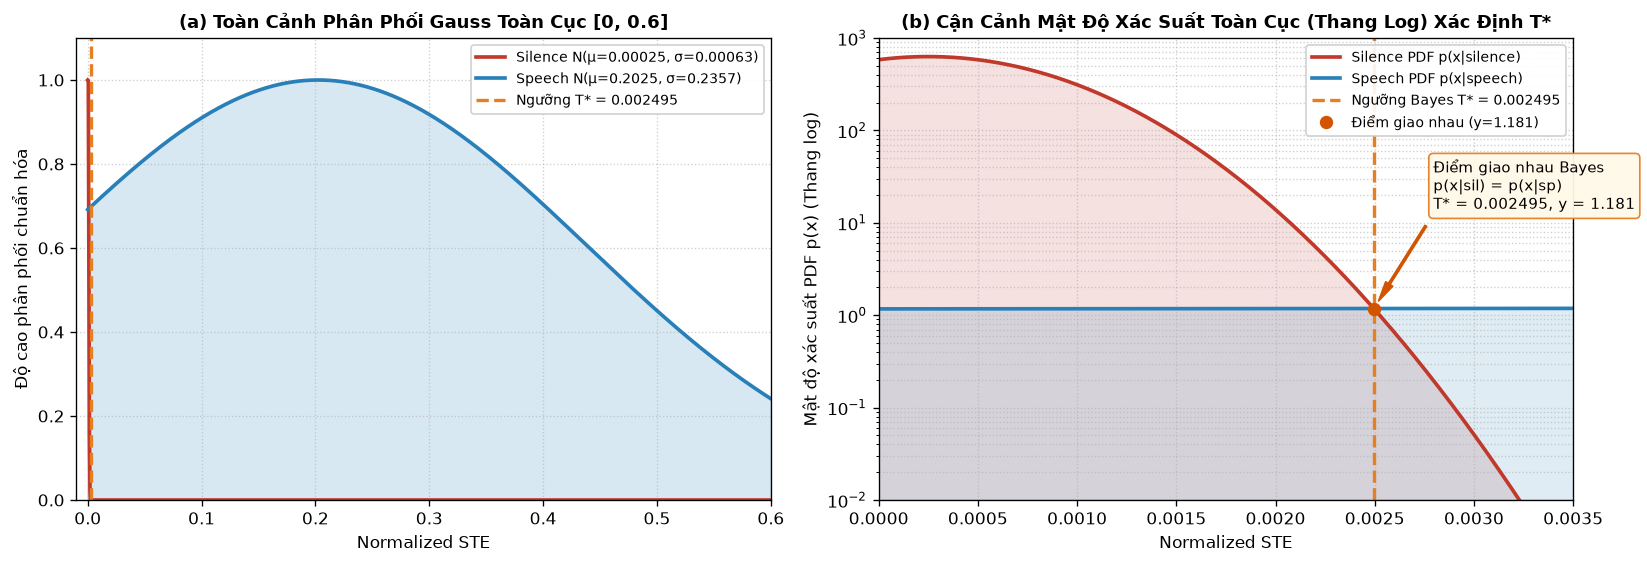

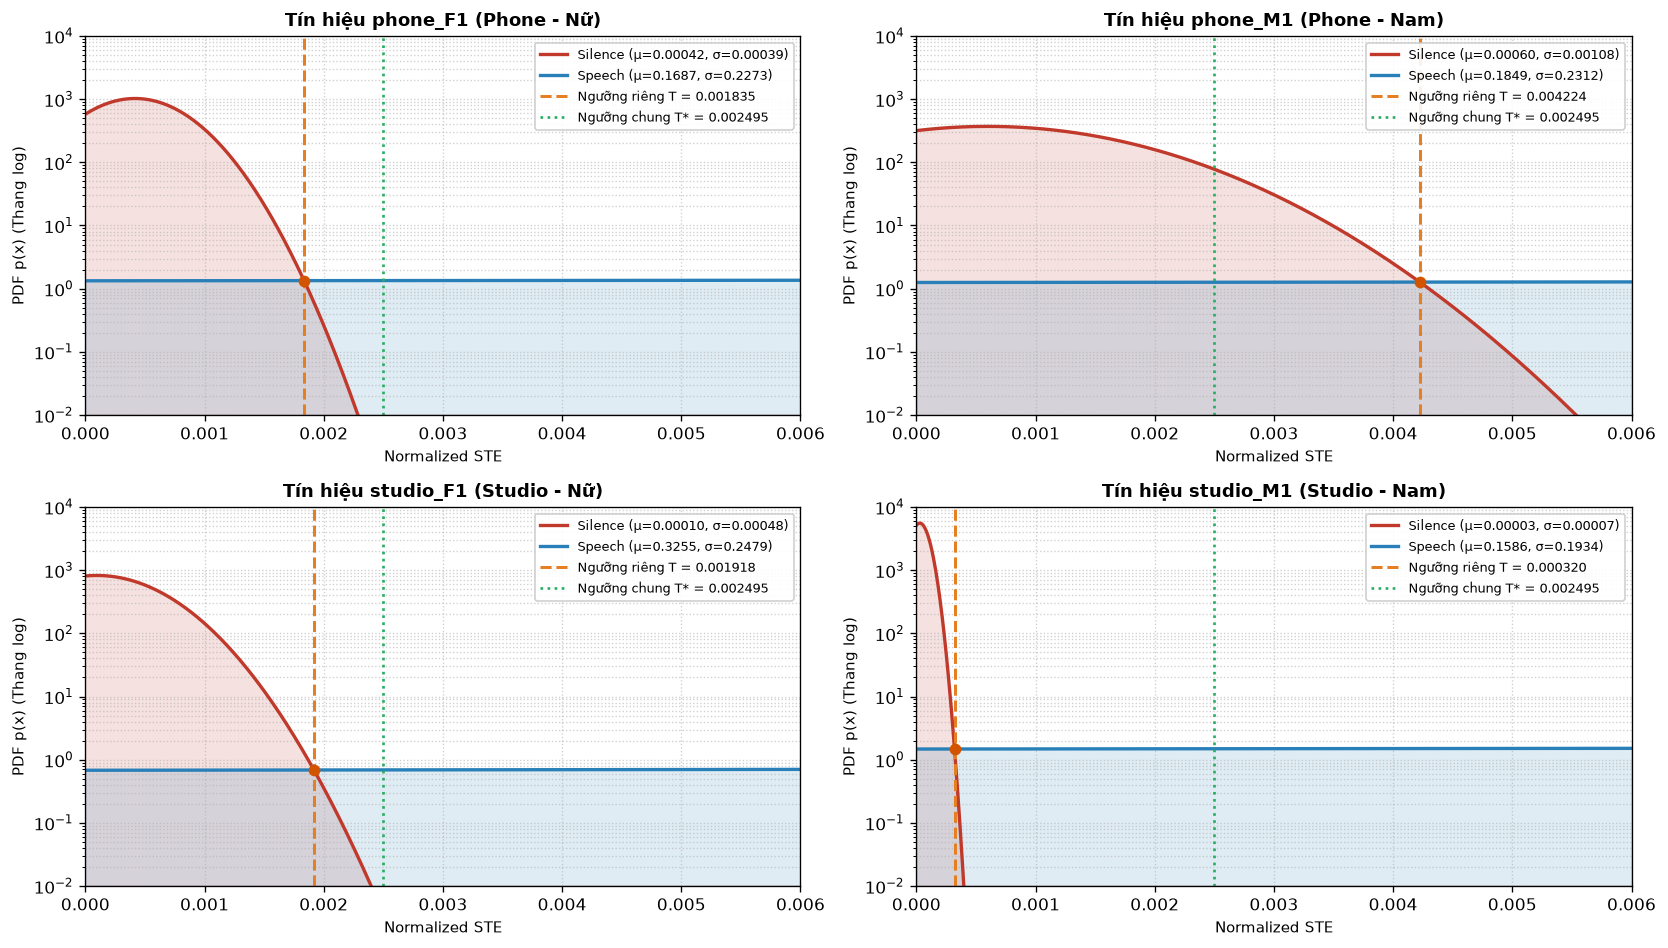

In [23]:
def gaussian_pdf(x: np.ndarray, mean: float, std: float) -> np.ndarray:
    """Hàm mật độ xác suất phân phối chuẩn Gauss thuần NumPy."""
    return (1.0 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)


# 1. Bảng thống kê định lượng trên từng file huấn luyện
print("=" * 88)
print("       BẢNG KẾT QUẢ ĐỊNH LƯỢNG THAM SỐ PHÂN PHỐI GAUSS TRÊN TẬP HUẤN LUYỆN")
print("=" * 88)
print(f"{'Tên File':<12} {'N_sil':<8} {'N_sp':<8} {'mean_sil':<13} {'std_sil':<13} {'mean_sp':<13} {'std_sp':<13} {'Ngưỡng T':<10}")
print("-" * 88)

file_stats = []
for sig in train_signals:
    frames, timestamps = apply_framing(sig.signal, sig.fs)
    ste_norm = normalize_minmax(compute_ste(frames))
    lbls = np.zeros(len(timestamps), dtype=int)
    for s_start, s_end in sig.gt_segments:
        lbls[(timestamps >= s_start) & (timestamps <= s_end)] = 1
    t_f, m_sp_f, s_sp_f, m_sil_f, s_sil_f = find_threshold_gaussian(ste_norm, lbls)
    file_stats.append({
        "name": sig.name,
        "m_sil": m_sil_f, "s_sil": s_sil_f,
        "m_sp": m_sp_f, "s_sp": s_sp_f,
        "t": t_f
    })
    print(f"{sig.name:<12} {np.sum(lbls == 0):<8} {np.sum(lbls == 1):<8} {m_sil_f:<13.6f} {s_sil_f:<13.6f} {m_sp_f:<13.6f} {s_sp_f:<13.6f} {t_f:<10.6f}")

print("-" * 88)
print(f"{'Toàn bộ':<12} {np.sum(all_labels == 0):<8} {np.sum(all_labels == 1):<8} {mean_sil:<13.6f} {std_sil:<13.6f} {mean_sp:<13.6f} {std_sp:<13.6f} {T_gaussian:<10.6f}")
print("=" * 88)

# 2. Đồ thị phân phối chuẩn Gauss toàn cục và vị trí ngưỡng tối ưu T* (2 Subplots)
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8), dpi=120)

# Subplot (a): Toàn cảnh 2 hình chuông phân phối Gauss [0.0, 0.6]
x_full = np.linspace(0.0, 0.6, 1200)
pdf_sil_full = gaussian_pdf(x_full, mean_sil, std_sil)
pdf_sp_full = gaussian_pdf(x_full, mean_sp, std_sp)

norm_sil_full = pdf_sil_full / np.max(pdf_sil_full)
norm_sp_full = pdf_sp_full / np.max(pdf_sp_full)

ax1.plot(x_full, norm_sil_full, color="#c0392b", linewidth=2.2, label=f"Silence N(μ={mean_sil:.5f}, σ={std_sil:.5f})")
ax1.fill_between(x_full, norm_sil_full, alpha=0.18, color="#c0392b")
ax1.plot(x_full, norm_sp_full, color="#2980b9", linewidth=2.2, label=f"Speech N(μ={mean_sp:.4f}, σ={std_sp:.4f})")
ax1.fill_between(x_full, norm_sp_full, alpha=0.18, color="#2980b9")
ax1.axvline(T_gaussian, color="#e67e22", linestyle="--", linewidth=2.0, label=f"Ngưỡng T* = {T_gaussian:.6f}")
ax1.set_title("(a) Toàn Cảnh Phân Phối Gauss Toàn Cục [0, 0.6]", fontsize=11, fontweight="bold")
ax1.set_xlabel("Normalized STE", fontsize=10)
ax1.set_ylabel("Độ cao phân phối chuẩn hóa", fontsize=10)
ax1.set_xlim(-0.01, 0.6)
ax1.set_ylim(0, 1.1)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right", fontsize=8.5, framealpha=0.9)

# Subplot (b): Cận cảnh mật độ xác suất PDF (Thang Log) xác định ngưỡng Bayes T* [0.0, 0.0035]
x_zoom = np.linspace(0.0, 0.0035, 1000)
pdf_sil_zoom = gaussian_pdf(x_zoom, mean_sil, std_sil)
pdf_sp_zoom = gaussian_pdf(x_zoom, mean_sp, std_sp)
y_intersect = float(gaussian_pdf(np.array([T_gaussian]), mean_sp, std_sp)[0])

ax2.plot(x_zoom, pdf_sil_zoom, color="#c0392b", linewidth=2.2, label="Silence PDF p(x|silence)")
ax2.fill_between(x_zoom, 1e-2, pdf_sil_zoom, alpha=0.15, color="#c0392b")
ax2.plot(x_zoom, pdf_sp_zoom, color="#2980b9", linewidth=2.2, label="Speech PDF p(x|speech)")
ax2.fill_between(x_zoom, 1e-2, pdf_sp_zoom, alpha=0.15, color="#2980b9")

ax2.axvline(T_gaussian, color="#e67e22", linestyle="--", linewidth=2.0, label=f"Ngưỡng Bayes T* = {T_gaussian:.6f}")
ax2.plot(T_gaussian, y_intersect, "o", color="#d35400", markersize=7, zorder=5, label=f"Điểm giao nhau (y={y_intersect:.3f})")
ax2.set_yscale("log")

label_text = f"Điểm giao nhau Bayes\np(x|sil) = p(x|sp)\nT* = {T_gaussian:.6f}, y = {y_intersect:.3f}"
ax2.annotate(
    label_text,
    xy=(T_gaussian, y_intersect),
    xytext=(T_gaussian + 0.0003, y_intersect * 12),
    arrowprops=dict(facecolor="#d35400", edgecolor="#d35400", width=1.2, headwidth=5, shrink=0.08),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#fef9e7", edgecolor="#e67e22", alpha=0.95),
)

ax2.set_title("(b) Cận Cảnh Mật Độ Xác Suất Toàn Cục (Thang Log) Xác Định T*", fontsize=11, fontweight="bold")
ax2.set_xlabel("Normalized STE", fontsize=10)
ax2.set_ylabel("Mật độ xác suất PDF p(x) (Thang log)", fontsize=10)
ax2.set_xlim(0.0, 0.0035)
ax2.set_ylim(1e-2, 1e3)
ax2.grid(True, linestyle=":", alpha=0.6, which="both")
ax2.legend(loc="upper right", fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.show()

# 3. Đồ thị phân phối Gauss riêng lẻ từng file huấn luyện (Lưới 2x2 Subplots)
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8), dpi=120)
axes2 = axes2.flatten()

for idx, item in enumerate(file_stats):
    ax = axes2[idx]
    m_sil_f = item["m_sil"]
    s_sil_f = item["s_sil"]
    m_sp_f = item["m_sp"]
    s_sp_f = item["s_sp"]
    t_f = item["t"]
    name = item["name"]

    x_f = np.linspace(0.0, 0.006, 1000)
    pdf_sil_f = gaussian_pdf(x_f, m_sil_f, s_sil_f)
    pdf_sp_f = gaussian_pdf(x_f, m_sp_f, s_sp_f)
    y_int_f = float(gaussian_pdf(np.array([t_f]), m_sp_f, s_sp_f)[0])

    ax.plot(x_f, pdf_sil_f, color="#c0392b", linewidth=2.0, label=f"Silence (μ={m_sil_f:.5f}, σ={s_sil_f:.5f})")
    ax.fill_between(x_f, 1e-2, pdf_sil_f, alpha=0.15, color="#c0392b")
    ax.plot(x_f, pdf_sp_f, color="#2980b9", linewidth=2.0, label=f"Speech (μ={m_sp_f:.4f}, σ={s_sp_f:.4f})")
    ax.fill_between(x_f, 1e-2, pdf_sp_f, alpha=0.15, color="#2980b9")

    ax.axvline(t_f, color="#e67e22", linestyle="--", linewidth=1.8, label=f"Ngưỡng riêng T = {t_f:.6f}")
    ax.axvline(T_gaussian, color="#27ae60", linestyle=":", linewidth=1.6, label=f"Ngưỡng chung T* = {T_gaussian:.6f}")
    ax.plot(t_f, y_int_f, "o", color="#d35400", markersize=6, zorder=5)

    ax.set_yscale("log")
    ax.set_xlim(0.0, 0.006)
    ax.set_ylim(1e-2, 1e4)
    ax.grid(True, linestyle=":", alpha=0.6, which="both")
    env_str = "Phone" if "phone" in name else "Studio"
    gender_str = "Nữ" if "F" in name else "Nam"
    ax.set_title(f"Tín hiệu {name} ({env_str} - {gender_str})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Normalized STE", fontsize=9)
    ax.set_ylabel("PDF p(x) (Thang log)", fontsize=9)
    ax.legend(loc="upper right", fontsize=8.0, framealpha=0.9)

plt.tight_layout()
plt.show()


In [24]:
def filter_short_silence(
    decisions: np.ndarray,
    frame_shift_ms: float = 10.0,
    min_silence_ms: float = 200.0,
) -> np.ndarray:
    """Lọc và gộp các khoảng lặng có thời lượng < 200ms vào tiếng nói."""
    filtered = np.copy(decisions)
    num_frames = len(filtered)
    min_sil_frames = int(round(min_silence_ms / frame_shift_ms))

    in_silence = False
    sil_start = 0

    for i in range(num_frames):
        if filtered[i] == 0:
            if not in_silence:
                in_silence = True
                sil_start = i
        else:
            if in_silence:
                sil_duration_frames = i - sil_start
                if sil_duration_frames < min_sil_frames and sil_start > 0:
                    filtered[sil_start:i] = 1
                in_silence = False

    if in_silence:
        sil_duration_frames = num_frames - sil_start
        if sil_duration_frames < min_sil_frames and sil_start > 0:
            filtered[sil_start:num_frames] = 1

    return filtered


def extract_boundaries(timestamps: np.ndarray, decisions: np.ndarray) -> list[float]:
    """Trích xuất mốc thời gian tại các điểm thay đổi nhãn phân đoạn."""
    boundaries = []
    for i in range(1, len(decisions)):
        if decisions[i] != decisions[i - 1]:
            boundaries.append(round(float(timestamps[i]), 6))
    return boundaries


In [25]:
def match_boundaries(
    predicted_boundaries: list[float],
    gt_boundaries: list[float],
) -> list[tuple[float, float]]:
    """Ghép cặp các biên dự đoán với biên chuẩn gần nhất."""
    pred_sorted = sorted(predicted_boundaries)
    gt_sorted = sorted(gt_boundaries)

    pairs = []
    if not pred_sorted or not gt_sorted:
        return pairs

    if len(pred_sorted) == len(gt_sorted):
        for i in range(len(gt_sorted)):
            pairs.append((pred_sorted[i], gt_sorted[i]))
    else:
        for target_gt in gt_sorted:
            best_pred = min(pred_sorted, key=lambda p: abs(p - target_gt))
            pairs.append((best_pred, target_gt))

    return pairs


def compute_mae(predicted_boundaries: list[float], gt_boundaries: list[float]) -> float:
    """Tính sai số tuyệt đối trung bình (MAE) theo giây."""
    pairs = match_boundaries(predicted_boundaries, gt_boundaries)
    if not pairs:
        return 0.0
    return float(np.mean([abs(p - g) for p, g in pairs]))


def compute_rmse(predicted_boundaries: list[float], gt_boundaries: list[float]) -> float:
    """Tính căn bậc hai sai số toàn phương trung bình (RMSE) theo giây."""
    pairs = match_boundaries(predicted_boundaries, gt_boundaries)
    if not pairs:
        return 0.0
    return float(np.sqrt(np.mean([(p - g)**2 for p, g in pairs])))


def calculate_snr_db(signal: np.ndarray, speech_segments: list[tuple[float, float]], fs: int) -> float:
    """Tính tỷ số tín hiệu trên nhiễu SNR (dB) của môi trường thu âm."""
    speech_mask = np.zeros(len(signal), dtype=bool)
    for s_start, s_end in speech_segments:
        idx_start = max(0, int(round(s_start * fs)))
        idx_end = min(len(signal), int(round(s_end * fs)))
        speech_mask[idx_start:idx_end] = True

    speech_samples = signal[speech_mask]
    noise_samples = signal[~speech_mask]

    p_speech = np.mean(speech_samples**2) if len(speech_samples) > 0 else 0.0
    p_noise = np.mean(noise_samples**2) if len(noise_samples) > 0 else 0.0

    if p_noise == 0 or p_speech == 0:
        return 0.0
    return float(10.0 * np.log10(p_speech / p_noise))


### 4. Phân đoạn trên tập Kiểm thử, Đánh giá định lượng & Trực quan hóa


In [26]:
test_signals = load_dataset("TinHieuKiemThu")
results_summary = []

for sig in test_signals:
    frames, timestamps = apply_framing(sig.signal, sig.fs)
    ste_raw = compute_ste(frames)
    ste_norm = normalize_minmax(ste_raw)
    f0_hz = estimate_f0_track(sig.signal, sig.fs, timestamps)

    raw_decisions = (ste_norm >= T_gaussian).astype(int)
    filtered_decisions = filter_short_silence(raw_decisions, frame_shift_ms=10.0, min_silence_ms=200.0)
    pred_boundaries = extract_boundaries(timestamps, filtered_decisions)

    mae_ms = compute_mae(pred_boundaries, sig.gt_boundaries) * 1000.0
    rmse_ms = compute_rmse(pred_boundaries, sig.gt_boundaries) * 1000.0
    snr_db = calculate_snr_db(sig.signal, sig.gt_segments, sig.fs)
    env_name = "Phone" if sig.is_phone else "Studio"

    results_summary.append({
        "name": sig.name,
        "env": env_name,
        "snr_db": snr_db,
        "mae_ms": mae_ms,
        "rmse_ms": rmse_ms,
        "sig": sig,
        "timestamps": timestamps,
        "ste_norm": ste_norm,
        "f0_hz": f0_hz,
        "pred_boundaries": pred_boundaries,
    })

print(f"{'Tên File':<12} {'Môi trường':<11} {'SNR (dB)':<10} {'MAE (ms)':<15} {'RMSE (ms)'}")
print("-" * 65)
for res in results_summary:
    print(f"{res['name']:<12} {res['env']:<11} {res['snr_db']:4.1f} dB   {res['mae_ms']:9.4f} ms    {res['rmse_ms']:9.4f} ms")
print("-" * 65)

phone_maes = [r["mae_ms"] for r in results_summary if r["env"] == "Phone"]
studio_maes = [r["mae_ms"] for r in results_summary if r["env"] == "Studio"]
all_maes = [r["mae_ms"] for r in results_summary]

print(f"{'TB Phone':<12} {'Phone (2 file)':<21} {np.mean(phone_maes):9.4f} ms")
print(f"{'TB Studio':<12} {'Studio (2 file)':<21} {np.mean(studio_maes):9.4f} ms")
print(f"{'Toàn bộ':<12} {'Overall (4 file)':<21} {np.mean(all_maes):9.4f} ms")


Tên File     Môi trường  SNR (dB)   MAE (ms)        RMSE (ms)
-----------------------------------------------------------------
phone_F2     Phone       24.8 dB     27.5000 ms      37.1652 ms
phone_M2     Phone       27.0 dB      2.5000 ms       2.5000 ms
studio_F2    Studio      49.3 dB      5.0000 ms       5.5929 ms
studio_M2    Studio      37.7 dB     12.4940 ms      16.0031 ms
-----------------------------------------------------------------
TB Phone     Phone (2 file)          15.0000 ms
TB Studio    Studio (2 file)          8.7470 ms
Toàn bộ      Overall (4 file)        11.8735 ms


/tmp/ipykernel_50847/3172535124.py:15: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wav.read(wav_path)


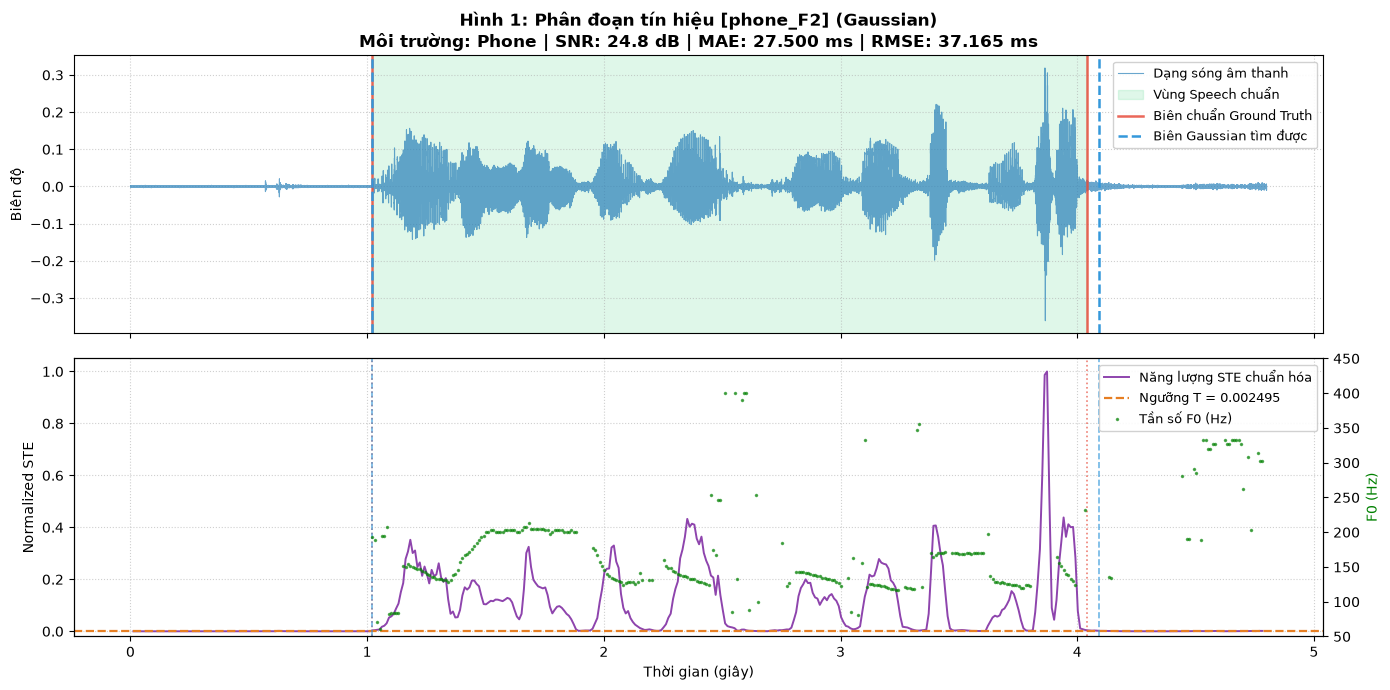

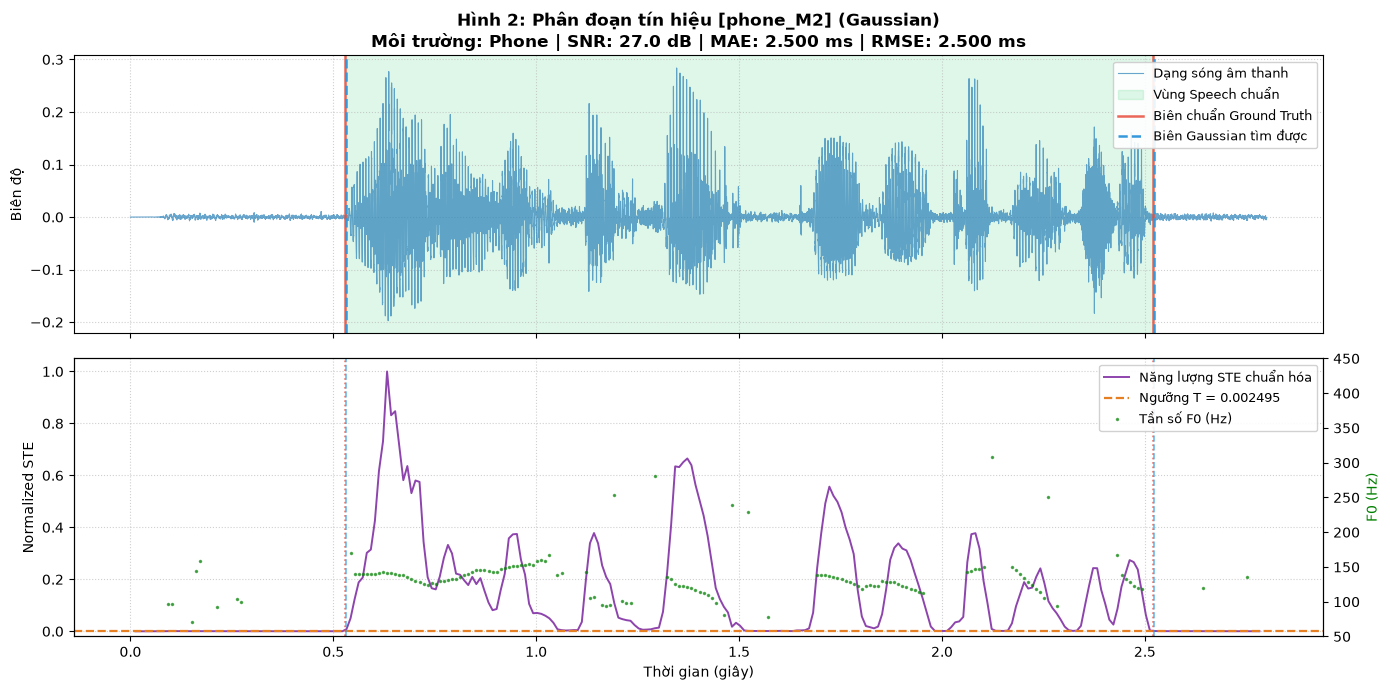

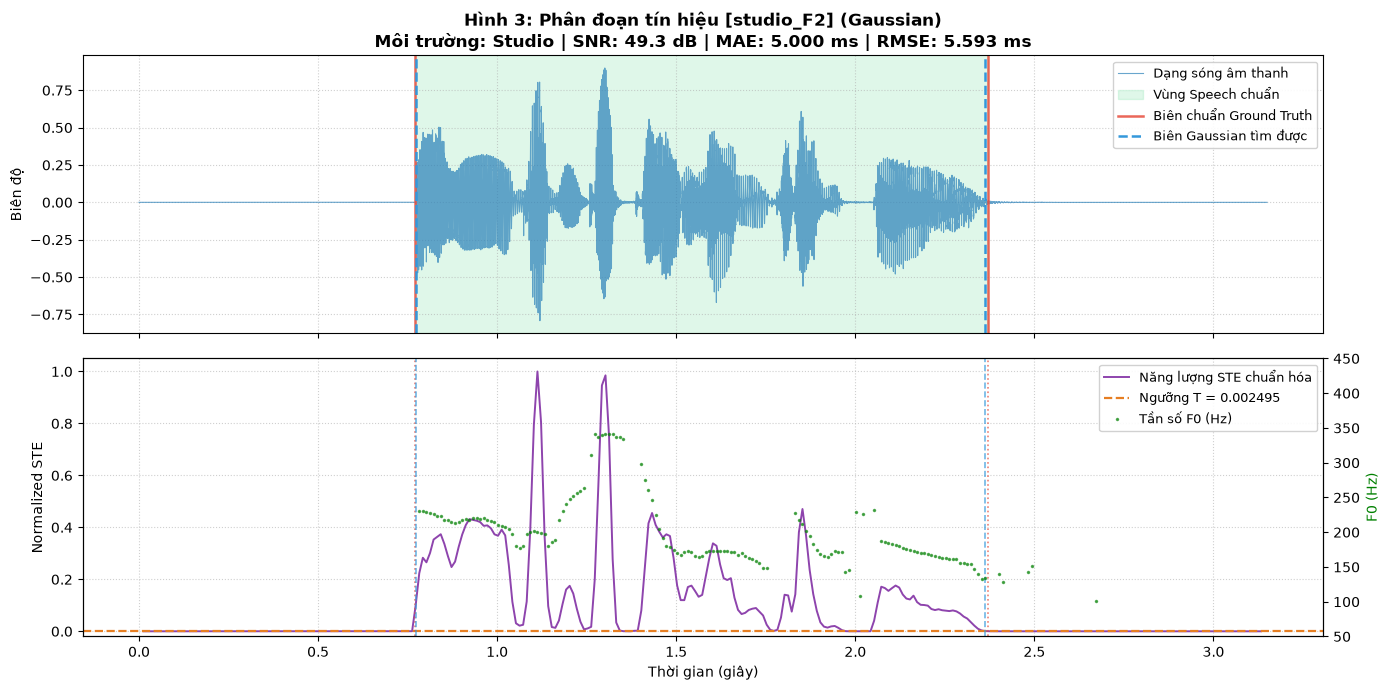

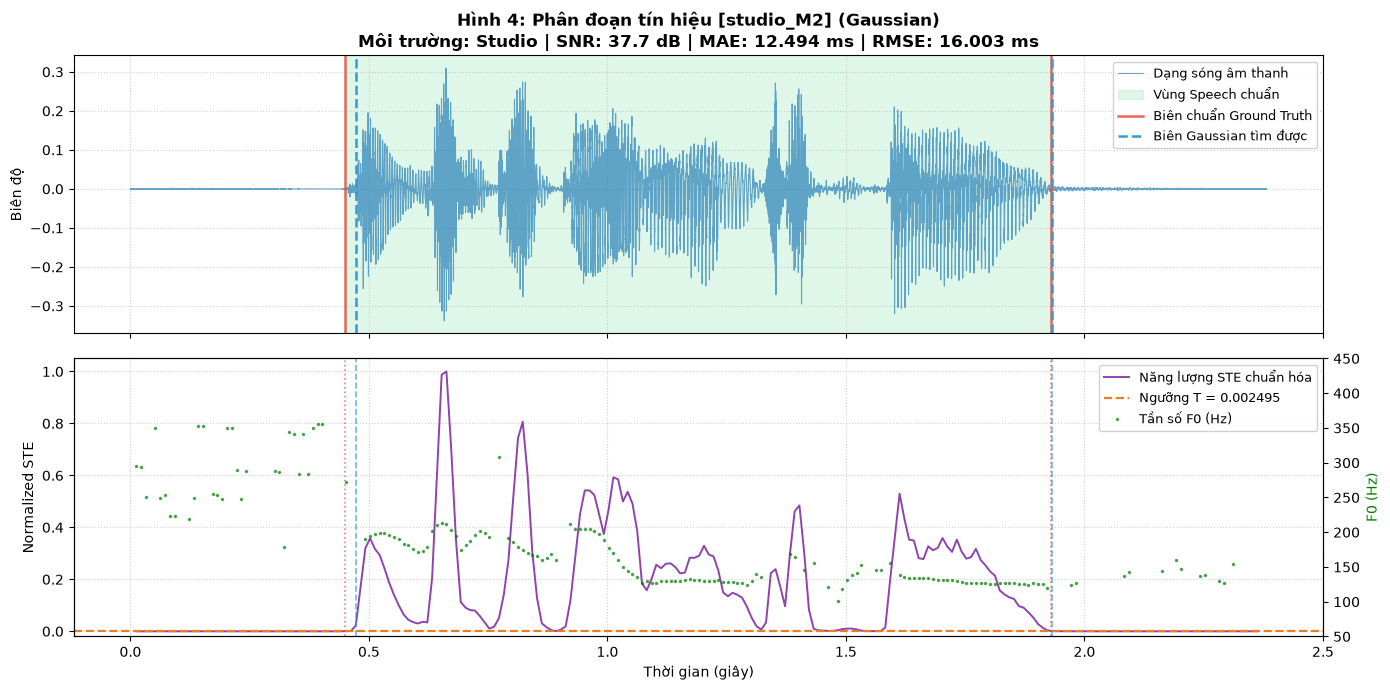

In [27]:
for i, res in enumerate(results_summary, start=1):
    sig = res["sig"]
    timestamps = res["timestamps"]
    ste_norm = res["ste_norm"]
    f0_hz = res["f0_hz"]
    pred_boundaries = res["pred_boundaries"]
    time_axis = np.linspace(0.0, sig.duration_sec, len(sig.signal))

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 7), sharex=True)

    ax1.plot(time_axis, sig.signal, color="#2980b9", alpha=0.7, linewidth=0.8, label="Dạng sóng âm thanh")
    for j, (start_t, end_t) in enumerate(sig.gt_segments):
        ax1.axvspan(start_t, end_t, color="#2ecc71", alpha=0.15, label="Vùng Speech chuẩn" if j == 0 else "")

    for j, gt_t in enumerate(sig.gt_boundaries):
        ax1.axvline(gt_t, color="#e74c3c", linestyle="-", linewidth=1.8, alpha=0.85, label="Biên chuẩn Ground Truth" if j == 0 else "")

    for j, pred_t in enumerate(pred_boundaries):
        ax1.axvline(pred_t, color="#3498db", linestyle="--", linewidth=1.8, label="Biên Gaussian tìm được" if j == 0 else "")

    ax1.set_title(
        f"Hình {i}: Phân đoạn tín hiệu [{sig.name}] (Gaussian)\n"
        f"Môi trường: {res['env']} | SNR: {res['snr_db']:.1f} dB | MAE: {res['mae_ms']:.3f} ms | RMSE: {res['rmse_ms']:.3f} ms",
        fontsize=12, fontweight="bold"
    )
    ax1.set_ylabel("Biên độ", fontsize=10)
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend(loc="upper right", framealpha=0.9, fontsize=9)

    ax2.plot(timestamps, ste_norm, color="#8e44ad", linewidth=1.4, label="Năng lượng STE chuẩn hóa")
    ax2.axhline(T_gaussian, color="#e67e22", linestyle="--", linewidth=1.6, label=f"Ngưỡng T = {T_gaussian:.6f}")

    for gt_t in sig.gt_boundaries:
        ax2.axvline(gt_t, color="#e74c3c", linestyle=":", linewidth=1.2, alpha=0.7)
    for pred_t in pred_boundaries:
        ax2.axvline(pred_t, color="#3498db", linestyle="--", linewidth=1.2, alpha=0.7)

    ax2.set_ylabel("Normalized STE", fontsize=10)
    ax2.set_xlabel("Thời gian (giây)", fontsize=10)
    ax2.set_ylim(-0.02, 1.05)
    ax2.grid(True, linestyle=":", alpha=0.6)

    ax2_f0 = ax2.twinx()
    valid_f0_mask = ~np.isnan(f0_hz)
    if np.any(valid_f0_mask):
        ax2_f0.plot(timestamps[valid_f0_mask], f0_hz[valid_f0_mask], "g.", markersize=3, alpha=0.6, label="Tần số F0 (Hz)")
        ax2_f0.set_ylabel("F0 (Hz)", color="green", fontsize=10)
        ax2_f0.set_ylim(50, 450)
    else:
        ax2_f0.set_yticks([])

    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_f0, labels_f0 = ax2_f0.get_legend_handles_labels()
    ax2.legend(lines_2 + lines_f0, labels_2 + labels_f0, loc="upper right", framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.show()
